# Import Library

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime
import sklearn
import itertools
import warnings
import os
import io
import plotly.offline as py #visualization
import plotly.graph_objs as go #visualization
import plotly.tools as tls #visualization
import plotly.figure_factory as ff #visualization
from matplotlib import pyplot
import xgboost as xgb
from xgboost import plot_importance
import gc
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, _CalibratedClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,BaggingClassifier,AdaBoostClassifier
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, r2_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier
from __future__ import print_function
from sklearn import metrics
warnings.filterwarnings("ignore")
py.init_notebook_mode(connected=True) #visualization
%matplotlib inline
pd.options.display.max_rows = 200
pd.options.display.max_columns = None

# Import Data

In [20]:
df = pd.read_csv("df_traveloka_03032022.csv",delimiter=',')
#define dependent and independent variable
y = df['is_churn']
X = df.drop(['is_churn','profile_id'],axis=1)
#split train and test data before do some missing value analysis
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
dftrain = pd.concat([X_train, y_train],axis=1)
dftest = pd.concat([X_test, y_test],axis=1)

In [21]:
dftrain.head()

,primary_sales_product_type,diff_last_issued_booking_time_hours,avg_issued_invoice_amount_idr,pct_succes_trx,avg_booking_invoice_amount_idr,count_issued,tenure_hours,invoice_per_count_issued,diff_last_first_booking_time_days,invoice_per_count_booking,count_booking,diff_last_first_issued_time_days,cluster,is_churn
115230,FLIGHT,23595.01,5.744485e+05,0.068966,1.101576e+06,2,4019.009400,2.872242e+05,1150.584001,37985.388823,29,111.072028,1,1
143895,HOTEL,18098.62,4.075790e+05,0.300000,3.491210e+05,3,4465.367714,1.358597e+05,940.166257,34912.100000,10,186.034164,0,1
200736,FLIGHT,0.13,1.049431e+06,0.650000,1.073872e+06,13,12850.276950,8.072543e+04,535.422694,53693.597500,20,535.422813,1,1
129827,FLIGHT,0.79,5.104693e+06,0.500000,4.242858e+06,3,2813.083815,1.701564e+06,117.178777,707143.000000,6,117.189334,0,1
30397,TRAIN,0.10,2.422750e+05,0.500000,2.422560e+05,1,0.178056,2.422750e+05,0.003426,121128.000000,2,0.000000,0,1


# Transform Features to WOE

In [22]:
# 1) function to transform : count_issued
def get_woe(x):
    y = None
    if x <= 1.5:
        y = 0
    elif (x <= 2.5) and (x > 1.5):
        y = 1
    elif (x <= 3.5) and (x > 2.5):
        y = 2
    elif (x <= 5.5) and (x > 3.5):
        y = 3
    elif (x <= 8.5) and (x > 5.5):
        y = 4
    elif (x <= 17.5) and (x > 8.5):
        y = 5
    else:
        y = 6
    return y
# transform
dftrain['count_issued_bin'] = dftrain['count_issued'].map(lambda x: get_woe(x))
dftest['count_issued_bin'] = dftest['count_issued'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 1.5:
        y = -0.577797*x
    elif (x <= 2.5) and (x > 1.5):
        y = -0.260221*x
    elif (x <= 3.5) and (x > 2.5):
        y = 0.019143*x
    elif (x <= 5.5) and (x > 3.5):
        y = 0.266142*x
    elif (x <= 8.5) and (x > 5.5):
        y = 0.574364*x
    elif (x <= 17.5) and (x > 8.5):
        y = 0.946399*x
    else:
        y = 1.615208*x
    return y
# transform
dftrain['count_issued_weighted'] = dftrain['count_issued'].map(lambda x: get_woe(x))
dftest['count_issued_weighted'] = dftest['count_issued'].map(lambda x: get_woe(x))

In [23]:
# 2) function to transform : invoice_per_count_booking - keep
def get_woe(x):
    y = None
    if x <= 11922.5859375:
        y = 0
    elif (x <= 24750.97753906) and (x > 11922.5859375):
        y = 1
    elif (x <= 37861.24609375) and (x > 24750.97753906):
        y = 2
    elif (x <= 49089.9765625) and (x > 37861.24609375):
        y = 3
    elif (x <= 72219.68359375) and (x > 49089.9765625):
        y = 4
    elif (x <= 88573.75390625) and (x > 72219.68359375):
        y = 5
    elif (x <= 108706.9609375) and (x > 88573.75390625):
        y = 6
    elif (x <= 134813.875) and (x > 108706.9609375):
        y = 7
    elif (x <= 165405.9375) and (x > 134813.875):
        y = 8
    elif (x <= 210600.4765625) and (x > 165405.9375):
        y = 9
    elif (x <= 307076.5) and (x > 210600.4765625):
        y = 10
    elif (x <= 390731.703125) and (x > 307076.5):
        y = 11
    elif (x <= 512066.796875) and (x > 390731.703125):
        y = 12
    else:
        y = 13
    return y
# transform
dftrain['invoice_per_count_booking_bin'] = dftrain['invoice_per_count_booking'].map(lambda x: get_woe(x))
dftest['invoice_per_count_booking_bin'] = dftest['invoice_per_count_booking'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 11922.5859375:
        y = 1.558254*x
    elif (x <= 24750.97753906) and (x > 11922.5859375):
        y = 0.929421*x
    elif (x <= 37861.24609375) and (x > 24750.97753906):
        y = 0.577767*x
    elif (x <= 49089.9765625) and (x > 37861.24609375):
        y = 0.414719*x
    elif (x <= 72219.68359375) and (x > 49089.9765625):
        y = 0.252769*x
    elif (x <= 88573.75390625) and (x > 72219.68359375):
        y = 0.051323*x
    elif (x <= 108706.9609375) and (x > 88573.75390625):
        y = 0.004558*x
    elif (x <= 134813.875) and (x > 108706.9609375):
        y = -0.084123*x
    elif (x <= 165405.9375) and (x > 134813.875):
        y = -0.140254*x
    elif (x <= 210600.4765625) and (x > 165405.9375):
        y = -0.272254*x
    elif (x <= 307076.5) and (x > 210600.4765625):
        y = -0.376266*x
    elif (x <= 390731.703125) and (x > 307076.5):
        y = -0.444362*x
    elif (x <= 512066.796875) and (x > 390731.703125):
        y = -0.467353*x
    else:
        y = -0.475158*x
    return y
# transform
dftrain['invoice_per_count_booking_weighted'] = dftrain['invoice_per_count_booking'].map(lambda x: get_woe(x))
dftest['invoice_per_count_booking_weighted'] = dftest['invoice_per_count_booking'].map(lambda x: get_woe(x))

In [24]:
# 3) function to transform : count_booking - keep
def get_woe(x):
    y = None
    if x <= 1.5:
        y = 0
    elif (x <= 2.5) and (x > 1.5):
        y = 1
    elif (x <= 3.5) and (x > 2.5):
        y = 2
    elif (x <= 4.5) and (x > 3.5):
        y = 3
    elif (x <= 5.5) and (x > 4.5):
        y = 4
    elif (x <= 7.5) and (x > 5.5):
        y = 5
    elif (x <= 9.5) and (x > 7.5):
        y = 6
    elif (x <= 12.5) and (x > 9.5):
        y = 7
    elif (x <= 16.5) and (x > 12.5):
        y = 8
    elif (x <= 27.5) and (x > 16.5):
        y = 9
    elif (x <= 47.5) and (x > 27.5):
        y = 10
    else:
        y = 11
    return y
# transform
dftrain['count_booking_bin'] = dftrain['count_booking'].map(lambda x: get_woe(x))
dftest['count_booking_bin'] = dftest['count_booking'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 1.5:
        y = -0.544464*x
    elif (x <= 2.5) and (x > 1.5):
        y = -0.496407*x
    elif (x <= 3.5) and (x > 2.5):
        y = -0.355312*x
    elif (x <= 4.5) and (x > 3.5):
        y = -0.276949*x
    elif (x <= 5.5) and (x > 4.5):
        y = -0.160569*x
    elif (x <= 7.5) and (x > 5.5):
        y = -0.068889*x
    elif (x <= 9.5) and (x > 7.5):
        y = 0.105735*x
    elif (x <= 12.5) and (x > 9.5):
        y = 0.227252*x
    elif (x <= 16.5) and (x > 12.5):
        y = 0.406555*x
    elif (x <= 27.5) and (x > 16.5):
        y = 0.680282*x
    elif (x <= 47.5) and (x > 27.5):
        y = 1.100952*x
    else:
        y = 1.605009*x
    return y
# transform
dftrain['count_booking_weighted'] = dftrain['count_booking'].map(lambda x: get_woe(x))
dftest['count_booking_weighted'] = dftest['count_booking'].map(lambda x: get_woe(x))

In [25]:
# 4) function to transform : pct_succes_trx - drop

In [26]:
# 5) function to transform : avg_booking_invoice_amount_idr - drop

In [27]:
# 6) function to transform : diff_last_issued_booking_time_hours - keep
def get_woe(x):
    y = None
    if x <= 3.49999992e-02:
        y = 0
    elif (x <= 5.49999997e-02) and (x > 3.49999992e-02):
        y = 1
    elif (x <= 7.49999993e-02) and (x > 5.49999997e-02):
        y = 2
    elif (x <= 9.50000025e-02) and (x > 7.49999993e-02):
        y = 3
    elif (x <= 1.34999998e-01) and (x > 9.50000025e-02):
        y = 4
    elif (x <= 1.85000002e-01) and (x > 1.34999998e-01):
        y = 5
    elif (x <= 4.77391504e+03) and (x > 1.85000002e-01):
        y = 6
    else:
        y = 7
    return y
# transform
dftrain['diff_last_issued_booking_time_hours_bin'] = dftrain['diff_last_issued_booking_time_hours'].map(lambda x: get_woe(x))
dftest['diff_last_issued_booking_time_hours_bin'] = dftest['diff_last_issued_booking_time_hours'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 3.49999992e-02:
        y = 0.785561*x
    elif (x <= 5.49999997e-02) and (x > 3.49999992e-02):
        y = 0.592202*x
    elif (x <= 7.49999993e-02) and (x > 5.49999997e-02):
        y = 0.363008*x
    elif (x <= 9.50000025e-02) and (x > 7.49999993e-02):
        y = 0.264952*x
    elif (x <= 1.34999998e-01) and (x > 9.50000025e-02):
        y = 0.11244*x
    elif (x <= 1.85000002e-01) and (x > 1.34999998e-01):
        y = -0.0469*x
    elif (x <= 4.77391504e+03) and (x > 1.85000002e-01):
        y = -0.108454*x
    else:
        y = -1.91252*x
    return y
# transform
dftrain['diff_last_issued_booking_time_hours_weighted'] = dftrain['diff_last_issued_booking_time_hours'].map(lambda x: get_woe(x))
dftest['diff_last_issued_booking_time_hours_weighted'] = dftest['diff_last_issued_booking_time_hours'].map(lambda x: get_woe(x))

In [28]:
# 7) function to transform : tenure_hours - keep
def get_woe(x):
    y = None
    if x <= 1.18756467:
        y = 0
    elif (x <= 14.90961218) and (x > 1.18756467):
        y = 1
    elif (x <= 62.51024437) and (x > 14.90961218):
        y = 2
    elif (x <= 157.91420746) and (x > 62.51024437):
        y = 3
    elif (x <= 238.15359497) and (x > 157.91420746):
        y = 4
    elif (x <= 390.07376099) and (x > 238.15359497):
        y = 5
    elif (x <= 518.48294067) and (x > 390.07376099):
        y = 6
    elif (x <= 1020.92886353) and (x > 518.48294067):
        y = 7
    else:
        y = 8
    return y
# transform
dftrain['diff_last_first_issued_time_days_bin'] = dftrain['diff_last_first_issued_time_days'].map(lambda x: get_woe(x))
dftest['diff_last_first_issued_time_days_bin'] = dftest['diff_last_first_issued_time_days'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 1.18756467:
        y = -0.579655*x
    elif (x <= 14.90961218) and (x > 1.18756467):
        y = -0.46202*x
    elif (x <= 62.51024437) and (x > 14.90961218):
        y = -0.396538*x
    elif (x <= 157.91420746) and (x > 62.51024437):
        y = -0.162077*x
    elif (x <= 238.15359497) and (x > 157.91420746):
        y = 0.086707*x
    elif (x <= 390.07376099) and (x > 238.15359497):
        y = 0.496989*x
    elif (x <= 518.48294067) and (x > 390.07376099):
        y = 0.870731*x
    elif (x <= 1020.92886353) and (x > 518.48294067):
        y = 1.013274*x
    else:
        y = 2.13551*x
    return y
# transform
dftrain['diff_last_first_issued_time_days_weighted'] = dftrain['diff_last_first_issued_time_days'].map(lambda x: get_woe(x))
dftest['diff_last_first_issued_time_days_weighted'] = dftest['diff_last_first_issued_time_days'].map(lambda x: get_woe(x))

In [29]:
# 8) function to transform : avg_issued_invoice_amount_idr - drop

In [30]:
# 9) function to transform : invoice_per_count_issued - keep
def get_woe(x):
    y = None
    if x <= 24994.96484375:
        y = 0
    elif (x <= 41653.02148438) and (x > 24994.96484375):
        y = 1
    elif (x <= 68428.05078125) and (x > 41653.02148438):
        y = 2
    elif (x <= 110447.8125) and (x > 68428.05078125):
        y = 3
    elif (x <= 160333.03125) and (x > 110447.8125):
        y = 4
    elif (x <= 211070.0859375) and (x > 160333.03125):
        y = 5
    elif (x <= 260403.25) and (x > 211070.0859375):
        y = 6
    elif (x <= 317137.515625) and (x > 260403.25):
        y = 7
    elif (x <= 390774.796875) and (x > 317137.515625):
        y = 8
    elif (x <= 524922.75) and (x > 390774.796875):
        y = 9
    else:
        y = 10
    return y
# transform
dftrain['invoice_per_count_issued_bin'] = dftrain['invoice_per_count_issued'].map(lambda x: get_woe(x))
dftest['invoice_per_count_issued_bin'] = dftest['invoice_per_count_issued'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 24994.96484375:
        y = 1.813614*x
    elif (x <= 41653.02148438) and (x > 24994.96484375):
        y = 1.17873*x
    elif (x <= 68428.05078125) and (x > 41653.02148438):
        y = 0.832647*x
    elif (x <= 110447.8125) and (x > 68428.05078125):
        y = 0.476762*x
    elif (x <= 160333.03125) and (x > 110447.8125):
        y = 0.215384*x
    elif (x <= 211070.0859375) and (x > 160333.03125):
        y = 0.03316*x
    elif (x <= 260403.25) and (x > 211070.0859375):
        y = -0.131056*x
    elif (x <= 317137.515625) and (x > 260403.25):
        y = -0.222817*x
    elif (x <= 390774.796875) and (x > 317137.515625):
        y = -0.384437*x
    elif (x <= 524922.75) and (x > 390774.796875):
        y = -0.470519*x
    else:
        y = -0.494898*x
    return y
# transform
dftrain['invoice_per_count_issued_weighted'] = dftrain['invoice_per_count_issued'].map(lambda x: get_woe(x))
dftest['invoice_per_count_issued_weighted'] = dftest['invoice_per_count_issued'].map(lambda x: get_woe(x))

In [31]:
# 10) function to transform : tenure_hours - keep
def get_woe(x):
    y = None
    if x <= 106.99559402:
        y = 0
    elif (x <= 768.73907471) and (x > 106.99559402):
        y = 1
    elif (x <= 2204.93713379) and (x > 768.73907471):
        y = 2
    elif (x <= 3790.53918457) and (x > 2204.93713379):
        y = 3
    elif (x <= 5737.80737305) and (x > 3790.53918457):
        y = 4
    elif (x <= 9313.74511719) and (x > 5737.80737305):
        y = 5
    elif (x <= 11997.57910156) and (x > 9313.74511719):
        y = 6
    elif (x <= 24650.60839844) and (x > 11997.57910156):
        y = 7
    else:
        y = 8
    return y
# transform
dftrain['tenure_hours_bin'] = dftrain['tenure_hours'].map(lambda x: get_woe(x))
dftest['tenure_hours_bin'] = dftest['tenure_hours'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 106.99559402:
        y = -0.620084*x
    elif (x <= 768.73907471) and (x > 106.99559402):
        y = -0.561557*x
    elif (x <= 2204.93713379) and (x > 768.73907471):
        y = -0.427654*x
    elif (x <= 3790.53918457) and (x > 2204.93713379):
        y = -0.23482*x
    elif (x <= 5737.80737305) and (x > 3790.53918457):
        y = -0.020063*x
    elif (x <= 9313.74511719) and (x > 5737.80737305):
        y = 0.398719*x
    elif (x <= 11997.57910156) and (x > 9313.74511719):
        y = 0.778363*x
    elif (x <= 24650.60839844) and (x > 11997.57910156):
        y = 0.863277*x
    else:
        y = 1.922502*x
    return y
# transform
dftrain['tenure_hours_weighted'] = dftrain['tenure_hours'].map(lambda x: get_woe(x))
dftest['tenure_hours_weighted'] = dftest['tenure_hours'].map(lambda x: get_woe(x))

In [32]:
# 11) function to transform : diff_last_first_booking_time_days - keep
def get_woe(x):
    y = None
    if x <= 1.02275133e+00:
        y = 0
    elif (x <= 8.35938358e+00) and (x > 1.02275133e+00):
        y = 1
    elif (x <= 3.47302113e+01) and (x > 8.35938358e+00):
        y = 2
    elif (x <= 9.18764381e+01) and (x > 3.47302113e+01):
        y = 3
    elif (x <= 1.57934204e+02) and (x > 9.18764381e+01):
        y = 4
    elif (x <= 2.60040085e+02) and (x > 1.57934204e+02):
        y = 5
    elif (x <= 3.90173218e+02) and (x > 2.60040085e+02):
        y = 6
    elif (x <= 4.98582336e+02) and (x > 3.90173218e+02):
        y = 7
    elif (x <= 8.62292450e+02) and (x > 4.98582336e+02):
        y = 8
    elif (x <= 1.09804688e+03) and (x > 8.62292450e+02):
        y = 9
    else:
        y = 10
    return y
# transform
dftrain['diff_last_first_booking_time_days_bin'] = dftrain['diff_last_first_booking_time_days'].map(lambda x: get_woe(x))
dftest['diff_last_first_booking_time_days_bin'] = dftest['diff_last_first_booking_time_days'].map(lambda x: get_woe(x))

def get_woe(x):
    y = None
    if x <= 1.02275133e+00:
        y = -0.542795*x
    elif (x <= 8.35938358e+00) and (x > 1.02275133e+00):
        y = -0.487753*x
    elif (x <= 3.47302113e+01) and (x > 8.35938358e+00):
        y = -0.472353*x
    elif (x <= 9.18764381e+01) and (x > 3.47302113e+01):
        y = -0.340343*x
    elif (x <= 1.57934204e+02) and (x > 9.18764381e+01):
        y = -0.229857*x
    elif (x <= 2.60040085e+02) and (x > 1.57934204e+02):
        y = -0.038568*x
    elif (x <= 3.90173218e+02) and (x > 2.60040085e+02):
        y = 0.220525*x
    elif (x <= 4.98582336e+02) and (x > 3.90173218e+02):
        y = 0.487439*x
    elif (x <= 8.62292450e+02) and (x > 4.98582336e+02):
        y = 0.606128*x
    elif (x <= 1.09804688e+03) and (x > 8.62292450e+02):
        y = 0.709661*x
    else:
        y = 1.397264*x
    return y
# transform
dftrain['diff_last_first_booking_time_days_weighted'] = dftrain['diff_last_first_booking_time_days'].map(lambda x: get_woe(x))
dftest['diff_last_first_booking_time_days_weighted'] = dftest['diff_last_first_booking_time_days'].map(lambda x: get_woe(x))

In [33]:
# 12) function to transform : cluster - keep

In [34]:
# 13) function to transform : primary_sales_product_type - keep
def get_woe(x):
    y = None
    if x in ('TRAIN', 'TRIP'):
        y = 0
    elif x == 'HOTEL':
        y = 1
    else:
        y = 2
    return y
# transform
dftrain['primary_sales_product_type_bin'] = dftrain['primary_sales_product_type'].map(lambda x: get_woe(x))
dftest['primary_sales_product_type_bin'] = dftest['primary_sales_product_type'].map(lambda x: get_woe(x))

# Initial Modelling - Logit Analysis

The challenges on this study use case is that i can't use logistic regression model, but i use this method just to 
provide an evidence that transforming features with optimum binning will be more importance than original

In [40]:
drop_col = ['is_churn','primary_sales_product_type','diff_last_issued_booking_time_hours',
            'avg_booking_invoice_amount_idr','cluster','count_issued','invoice_per_count_issued']
drop_col1 = [col for col in list(dftrain.columns) if '_weighted' in col]
# train
ytrain = dftrain['is_churn']
Xtrain = dftrain.drop(drop_col,axis=1)
Xtrain = Xtrain.drop(drop_col1,axis=1)
# Xtrain = pd.concat([Xtrain.drop('primary_sales_product_type_bin',axis=1),
#                     pd.get_dummies(Xtrain['primary_sales_product_type_bin'],drop_first=False).drop('OTHERS',axis=1)],
#                    axis=1)
# Xtrain = Xtrain[[col for col in list(Xtrain.columns) if ('_weighted' in col) or ('_bin' in col)]+['HOTEL','FLIGHT']]
# Xtrain = Xtrain.drop([col for col in list(Xtrain.columns) if '_weighted' in col],axis=1)

# test
ytest = dftest['is_churn']
Xtest = dftest.drop(drop_col,axis=1)
Xtest = Xtest.drop(drop_col1,axis=1)
# Xtest = pd.concat([Xtest.drop('primary_sales_product_type_bin',axis=1),
#                     pd.get_dummies(Xtest['primary_sales_product_type_bin'],drop_first=False).drop('OTHERS',axis=1)],
#                    axis=1)
# Xtest = Xtest[[col for col in list(Xtest.columns) if ('_weighted' in col) or ('_bin' in col)]+['HOTEL','FLIGHT']]
# Xtest = Xtest.drop([col for col in list(Xtest.columns) if '_weighted' in col],axis=1)


xtrain_col = Xtrain.columns
model_credit_scoring = sm.Logit(ytrain, Xtrain)
result_scoring = model_credit_scoring.fit()
result_scoring.summary()

Optimization terminated successfully.
         Current function value: 0.568403
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               is_churn   No. Observations:               164805
Model:                          Logit   Df Residuals:                   164789
Method:                           MLE   Df Model:                           15
Date:                Mon, 07 Mar 2022   Pseudo R-squ.:                  0.1538
Time:                        08:00:20   Log-Likelihood:                -93676.
converged:                       True   LL-Null:                   -1.1070e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================================
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
avg_issued_invoice_amount_idr           -2.987e-08   7.32e-09     -4.079      0.000   -4.42e-08   -1.55e-08
pct_succes_trx                             -0.5047      0.030    -16.963      0.000      -0.563      -0.446
tenure_hours                               -0.0003   5.98e-06    -51.131      0.000      -0.000      -0.000
diff_last_first_booking_time_days           0.0068      0.000     53.641      0.000       0.007       0.007
invoice_per_count_booking               -3.458e-08   1.02e-08     -3.395      0.001   -5.45e-08   -1.46e-08
count_booking                              -0.0059      0.001    -11.292      0.000      -0.007      -0.005
diff_last_first_issued_time_days           -0.0007   8.33e-05     -8.392      0.000      -0.001      -0.001
count_issued_bin                            0.0476      0.011      4.299      0.000       0.026       0.069
invoice_per_count_booking_bin              -0.0360      0.005     -7.349      0.000      -0.046      -0.026
count_booking_bin                          -0.1040      0.006    -18.886      0.000      -0.115      -0.093
diff_last_issued_booking_time_hours_bin     0.0614      0.003     21.075      0.000       0.056       0.067
diff_last_first_issued_time_days_bin        0.0165      0.009      1.751      0.080      -0.002       0.035
invoice_per_count_issued_bin                0.0116      0.006      2.075      0.038       0.001       0.023
tenure_hours_bin                            0.0262      0.012      2.231      0.026       0.003       0.049
diff_last_first_booking_time_days_bin      -0.1326      0.009    -14.714      0.000      -0.150      -0.115
primary_sales_product_type_bin              0.5986      0.009     65.420      0.000       0.581       0.617
===========================================================================================================
"""

In [41]:
0.0116*100

1.16

In [109]:
drop_col = ['is_churn','primary_sales_product_type','invoice_per_count_issued_weighted','invoice_per_count_issued_bin']
# train
ytrain = dftrain['is_churn']
Xtrain = dftrain.drop(drop_col,axis=1)
Xtrain = pd.concat([Xtrain.drop('primary_sales_product_type_bin',axis=1),
                    pd.get_dummies(Xtrain['primary_sales_product_type_bin'],drop_first=False).drop('OTHERS',axis=1)],
                   axis=1)
Xtrain = Xtrain[[col for col in list(Xtrain.columns) if ('_weighted' in col) or ('_bin' in col)]+['HOTEL','FLIGHT']]
# Xtrain = Xtrain.drop([col for col in list(Xtrain.columns) if '_weighted' in col],axis=1)

# test
ytest = dftest['is_churn']
Xtest = dftest.drop(drop_col,axis=1)
Xtest = pd.concat([Xtest.drop('primary_sales_product_type_bin',axis=1),
                    pd.get_dummies(Xtest['primary_sales_product_type_bin'],drop_first=False).drop('OTHERS',axis=1)],
                   axis=1)
Xtest = Xtest[[col for col in list(Xtest.columns) if ('_weighted' in col) or ('_bin' in col)]+['HOTEL','FLIGHT']]
# Xtest = Xtest.drop([col for col in list(Xtest.columns) if '_weighted' in col],axis=1)


xtrain_col = Xtrain.columns
model_credit_scoring = sm.Logit(ytrain, Xtrain)
result_scoring = model_credit_scoring.fit()
result_scoring.summary()

Optimization terminated successfully.
         Current function value: 0.566746
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               is_churn   No. Observations:               164805
Model:                          Logit   Df Residuals:                   164789
Method:                           MLE   Df Model:                           15
Date:                Sun, 06 Mar 2022   Pseudo R-squ.:                  0.1563
Time:                        21:24:53   Log-Likelihood:                -93403.
converged:                       True   LL-Null:                   -1.1070e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================================
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
count_issued_bin                                -0.0615      0.008     -7.883      0.000      -0.077      -0.046
count_issued_weighted                           -0.0037      0.001     -4.585      0.000      -0.005      -0.002
invoice_per_count_booking_bin                   -0.0518      0.002    -30.573      0.000      -0.055      -0.049
invoice_per_count_booking_weighted            1.416e-07   1.31e-08     10.838      0.000    1.16e-07    1.67e-07
count_booking_bin                               -0.0605      0.004    -15.363      0.000      -0.068      -0.053
count_booking_weighted                          -0.0016      0.000     -4.059      0.000      -0.002      -0.001
diff_last_issued_booking_time_hours_bin          0.0635      0.003     23.480      0.000       0.058       0.069
diff_last_issued_booking_time_hours_weighted    -0.0001    3.2e-06    -43.763      0.000      -0.000      -0.000
diff_last_first_issued_time_days_bin            -0.0334      0.007     -4.827      0.000      -0.047      -0.020
diff_last_first_issued_time_days_weighted       -0.0002   3.32e-05     -6.194      0.000      -0.000      -0.000
tenure_hours_bin                                -0.1144      0.010    -11.916      0.000      -0.133      -0.096
tenure_hours_weighted                        -1.765e-05   2.57e-06     -6.862      0.000   -2.27e-05   -1.26e-05
diff_last_first_booking_time_days_bin           -0.0176      0.008     -2.252      0.024      -0.033      -0.002
diff_last_first_booking_time_days_weighted       0.0002   7.64e-05      2.416      0.016    3.48e-05       0.000
HOTEL                                            0.7950      0.018     45.074      0.000       0.760       0.830
FLIGHT                                           1.3005      0.019     69.403      0.000       1.264       1.337
================================================================================================================
"""

In [110]:
def plot_auc(ax, y_train=[], y_train_pred=[], y_test=[], y_test_pred=[]):
    
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        fpr_train, tpr_train, _ = roc_curve(y_train,y_train_pred)
        roc_auc_train = metrics.auc(fpr_train, tpr_train)
        ax.plot(fpr_train, tpr_train)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):        
        fpr_test, tpr_test, _ = roc_curve(y_test,y_test_pred)
        roc_auc_test = metrics.auc(fpr_test, tpr_test)
        ax.plot(fpr_test, tpr_test)        
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curve')
    train_text = None
    test_text = None
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        train_text = 'TRAIN auc = {:.2f}'.format(roc_auc_train)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):
        test_text = 'TEST  auc = {:.2f}'.format(roc_auc_test)
    leg = []
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        leg.append(train_text)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):
        leg.append(test_text)
    ax.legend(leg)    

Best Accuracy 0.6403507175146385
Best Param {'C': 0.0001}
AUC Train Score =  0.7089128862310781
AUC Test Score =  0.7099454331054136


<AxesSubplot:xlabel='feature coefficients', ylabel='feature name'>

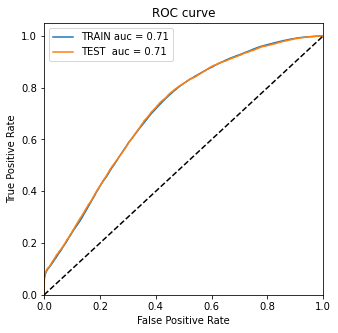

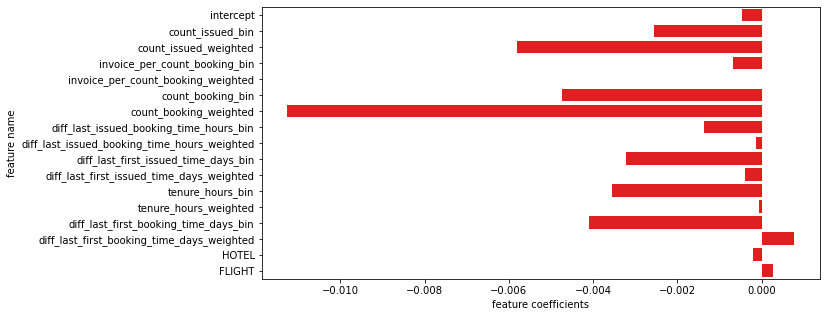

In [89]:
import time
start_time = time.time()
def logreg_fit(x_train, y_train):
    logreg = LogisticRegression()
    hyperparam = {'C': [1000, 333.33, 100, 33.33, 10, 3.33, 10, 3.33, 1, 0.33, 0.1, 0.033, 0.01, 0.0033, 
                        0.001, 0.00033, 0.0001]}
    random_logreg = RandomizedSearchCV(logreg, param_distributions = hyperparam, cv = 5,
                                    n_iter = 10, n_jobs=2, random_state = 123)
    
    random_logreg.fit(x_train, y_train)    
    print ("Best Accuracy", random_logreg.best_score_)
    print ("Best Param", random_logreg.best_params_)    
    return random_logreg

best_logreg = logreg_fit(Xtrain, ytrain) 
logreg = LogisticRegression(C=best_logreg.best_params_.get('C'))
logreg.fit(Xtrain, ytrain)
# Check performa dari model menggunakan auc score
roc_train=roc_auc_score(ytrain, logreg.predict_proba(Xtrain)[:,1])
print('AUC Train Score = ',roc_train)
roc_test=roc_auc_score(ytest, logreg.predict_proba(Xtest)[:,1])
print('AUC Test Score = ',roc_test)

#plot roc
fig,ax = plt.subplots(1)
fig.set_size_inches(5,5)
plot_auc(ax, 
         y_train=ytrain, 
         y_train_pred=logreg.predict_proba(Xtrain)[:,1], 
         y_test=ytest, 
         y_test_pred=logreg.predict_proba(Xtest)[:,1]
        )

#plot coeficient
coef = logreg.coef_[0].tolist()
coef.insert(0,logreg.intercept_[0])
basket = pd.concat(
[pd.Series(['intercept']+list(Xtrain.columns),name='feature name'),
pd.Series(coef,name='feature coefficients')],
axis=1)
plt.figure(figsize=(10,5))
sns.barplot(basket['feature coefficients'],basket['feature name'],color='Red')

# Comparing Each Model To Get The Best Model

In [111]:
#check imbalance or not?
print("""After check distribution of default flag. the data is not imbalanced then for evaluation will be using
only brier score for make it simple due to limited time""")
ytrain.value_counts(True)

After check distribution of default flag. the data is not imbalanced then for evaluation will be using
only brier score for make it simple due to limited time


0    0.603137
1    0.396863
Name: is_churn, dtype: float64

In [112]:
model = []
auc_train = []
auc_test = []
accuracy_train = []
accuracy_test = []
precision_train = []
precision_test = []
recall_train = []
recall_test = []
f1_train = []
f1_test = []
delta_score = []
times = []

Best Accuracy 0.6903127939079517
Best Param {'n_estimators': 100, 'base_estimator__min_samples_split': 80, 'base_estimator__max_depth': 8}
AUC Train Score =  0.7631118153766263
AUC Test Score =  0.758050085471659


<Figure size 720x360 with 0 Axes>

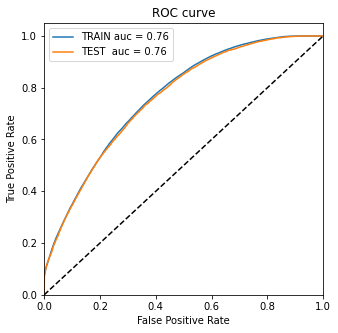

<Figure size 720x360 with 0 Axes>

In [55]:
#Build model with  Bagging
import time
start_time = time.time()
def bagging_fit(x_train, y_train, scoring = 'accuracy'):
    dectree = DecisionTreeClassifier(random_state=123)
    
    bagging = BaggingClassifier(base_estimator = dectree, 
                                random_state=123)
    
    hyperparam = {'base_estimator__min_samples_split': [3, 5, 7, 9, 13, 17, 21, 27, 33, 41, 50, 60, 80, 100],
                  'base_estimator__max_depth': [2, 4, 6, 8],
                  'n_estimators': [100, 200, 300, 500, 750, 1000]}
    random_bagging = RandomizedSearchCV(bagging, 
                                        param_distributions = hyperparam, 
                                        cv = 5, 
                                        n_iter = 10, 
                                        scoring = scoring,
                                        n_jobs = -1, 
                                        random_state = 123)
    
    random_bagging.fit(x_train, y_train)
    
    print("Best Accuracy", random_bagging.best_score_)
    print("Best Param", random_bagging.best_params_)
    return random_bagging
best_bagging = bagging_fit(Xtrain,ytrain)
dectree_bagging = DecisionTreeClassifier(min_samples_split = best_bagging.best_params_.get('base_estimator__min_samples_split'),
                                         max_depth = best_bagging.best_params_.get('base_estimator__max_depth'),
                                         random_state=123)
bagging = BaggingClassifier(base_estimator = dectree_bagging, 
                            n_estimators = best_bagging.best_params_.get('n_estimators'),
                            random_state=123, n_jobs=-1)

bagging.fit(Xtrain,ytrain)
roc_train=roc_auc_score(ytrain, bagging.predict_proba(Xtrain)[:,1])
print('AUC Train Score = ',roc_train)
roc_test=roc_auc_score(ytest, bagging.predict_proba(Xtest)[:,1])
print('AUC Test Score = ',roc_test)
#input result
model.append('bagging')
auc_train.append(roc_train)
auc_test.append(roc_test)
accuracy_train.append(accuracy_score(ytrain, bagging.predict(Xtrain)))
accuracy_test.append(accuracy_score(ytest, bagging.predict(Xtest)))
precision_train.append(precision_score(ytrain, bagging.predict(Xtrain)))
precision_test.append(precision_score(ytest, bagging.predict(Xtest)))
recall_train.append(recall_score(ytrain, bagging.predict(Xtrain)))
recall_test.append(recall_score(ytest, bagging.predict(Xtest)))
f1_train.append(recall_score(ytrain, bagging.predict(Xtrain)))
f1_test.append(recall_score(ytest, bagging.predict(Xtest)))
delta_score.append(abs(roc_train-roc_test))
times.append(time.time() - start_time)

#plot auc
fig,ax = plt.subplots(1)
fig.set_size_inches(5,5)
plot_auc(ax, 
         y_train=ytrain, 
         y_train_pred=bagging.predict_proba(Xtrain)[:,1], 
         y_test=ytest, 
         y_test_pred=bagging.predict_proba(Xtest)[:,1]
        )
plt.figure(figsize=(10,5))

Best Accuracy 0.671235702800279
Best Param {'n_estimators': 100, 'learning_rate': 0.015, 'base_estimator__min_samples_split': 9, 'base_estimator__max_features': 0.25}
AUC Train Score =  1.0
AUC Test Score =  0.7354450144161326


<AxesSubplot:>

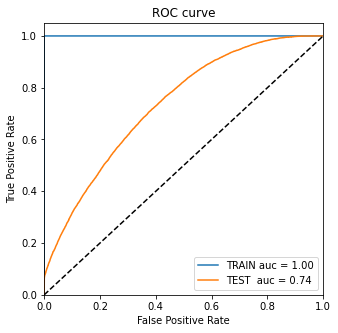

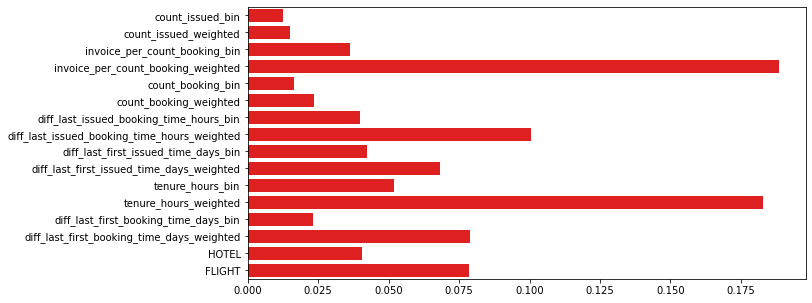

In [56]:
#Build model with  Adaboost
import time
start_time = time.time()
def adaboost_fit(x_train, y_train, scoring = 'accuracy'):
    dectree = DecisionTreeClassifier(random_state=123)    
    adaboost = AdaBoostClassifier(base_estimator = dectree,random_state=123)    
    hyperparam = {'base_estimator__min_samples_split': [3, 5, 7, 9, 
                                                       13, 17, 21, 27, 
                                                       33, 41, 50, 60, 
                                                       80, 100],
                  'base_estimator__max_features': ['sqrt', 'log2', 
                                                   0.25, 0.5, 0.75],
                  'learning_rate': [0.01, 0.015, 0.02, 
                                    0.05, 0.08, 0.1],
                  'n_estimators': [100, 200, 300, 
                                   500, 750, 1000]}    
    random_adaboost = RandomizedSearchCV(adaboost, 
                                         param_distributions = hyperparam, 
                                         cv = 5, 
                                         n_iter = 10, 
                                         scoring = scoring, 
                                         n_jobs=-1, 
                                         random_state = 123)    
    random_adaboost.fit(x_train, y_train)    
    print ("Best Accuracy", random_adaboost.best_score_)
    print ("Best Param", random_adaboost.best_params_)
    return random_adaboost
best_adaboost = adaboost_fit(Xtrain,ytrain)
dectree_boost = DecisionTreeClassifier(min_samples_split = best_adaboost.best_params_.get('base_estimator__min_samples_split'),
                                      max_features = best_adaboost.best_params_.get('base_estimator__max_features'),
                                      random_state=123)
adaboost = AdaBoostClassifier(base_estimator = dectree_boost, 
                             n_estimators = best_adaboost.best_params_.get('n_estimators'),
                             learning_rate = best_adaboost.best_params_.get('learning_rate'),
                             random_state=123)

adaboost.fit(Xtrain,ytrain)
roc_train=roc_auc_score(ytrain, adaboost.predict_proba(Xtrain)[:,1])
print('AUC Train Score = ',roc_train)
roc_test=roc_auc_score(ytest, adaboost.predict_proba(Xtest)[:,1])
print('AUC Test Score = ',roc_test)
#input result
model.append('adaboost')
auc_train.append(roc_train)
auc_test.append(roc_test)
accuracy_train.append(accuracy_score(ytrain, adaboost.predict(Xtrain)))
accuracy_test.append(accuracy_score(ytest, adaboost.predict(Xtest)))
precision_train.append(precision_score(ytrain, adaboost.predict(Xtrain)))
precision_test.append(precision_score(ytest, adaboost.predict(Xtest)))
recall_train.append(recall_score(ytrain, adaboost.predict(Xtrain)))
recall_test.append(recall_score(ytest, adaboost.predict(Xtest)))
f1_train.append(recall_score(ytrain, adaboost.predict(Xtrain)))
f1_test.append(recall_score(ytest, adaboost.predict(Xtest)))
delta_score.append(abs(roc_train-roc_test))
times.append(time.time() - start_time)

#plot auc
fig,ax = plt.subplots(1)
fig.set_size_inches(5,5)
plot_auc(ax, 
         y_train=ytrain, 
         y_train_pred=adaboost.predict_proba(Xtrain)[:,1], 
         y_test=ytest, 
         y_test_pred=adaboost.predict_proba(Xtest)[:,1]
        )
plt.figure(figsize=(10,5))

sns.barplot(list(adaboost.feature_importances_),list(Xtrain.columns),color='Red')

0:	learn: 0.6042840	total: 8.09ms	remaining: 801ms
1:	learn: 0.5890499	total: 16ms	remaining: 782ms
2:	learn: 0.5819409	total: 23.8ms	remaining: 771ms
3:	learn: 0.5765875	total: 31.5ms	remaining: 755ms
4:	learn: 0.5725583	total: 39.2ms	remaining: 746ms
5:	learn: 0.5709078	total: 49.7ms	remaining: 779ms
6:	learn: 0.5692208	total: 59.1ms	remaining: 785ms
7:	learn: 0.5683032	total: 66.8ms	remaining: 768ms
8:	learn: 0.5656043	total: 76ms	remaining: 769ms
9:	learn: 0.5648276	total: 84.9ms	remaining: 764ms
10:	learn: 0.5632997	total: 92.6ms	remaining: 750ms
11:	learn: 0.5623973	total: 100ms	remaining: 734ms
12:	learn: 0.5618138	total: 107ms	remaining: 719ms
13:	learn: 0.5616808	total: 115ms	remaining: 706ms
14:	learn: 0.5611050	total: 123ms	remaining: 699ms
15:	learn: 0.5608219	total: 131ms	remaining: 688ms
16:	learn: 0.5604933	total: 141ms	remaining: 689ms
17:	learn: 0.5603497	total: 152ms	remaining: 692ms
18:	learn: 0.5594879	total: 165ms	remaining: 703ms
19:	learn: 0.5592457	total: 175ms	

<Figure size 720x360 with 0 Axes>

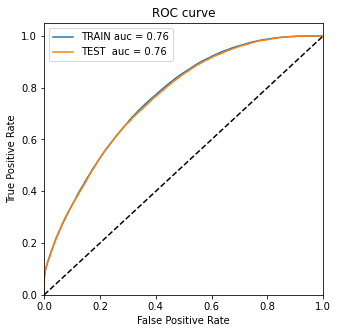

<Figure size 720x360 with 0 Axes>

In [117]:
# Initialize data
import time
start_time = time.time()
train_data = Xtrain 
train_labels = ytrain
test_data = Xtest 
test_labels = ytest
# Initialize CatBoostClassifier
catbo = CatBoostClassifier(iterations=100,learning_rate=1,depth=2)
# Fit model
catbo.fit(train_data, train_labels)
#evaluation metrics
roc_train=roc_auc_score(train_labels, catbo.predict_proba(train_data)[:,1])
roc_test=roc_auc_score(test_labels, catbo.predict_proba(test_data)[:,1])
print('AUC Train Score = ',roc_train)
print('AUC Test Score = ',roc_test)
# #input result
# model.append('catboost')
# auc_train.append(roc_train)
# auc_test.append(roc_test)
# accuracy_train.append(accuracy_score(ytrain, catbo.predict(Xtrain)))
# accuracy_test.append(accuracy_score(ytest, catbo.predict(Xtest)))
# precision_train.append(precision_score(ytrain, catbo.predict(Xtrain)))
# precision_test.append(precision_score(ytest, catbo.predict(Xtest)))
# recall_train.append(recall_score(ytrain, catbo.predict(Xtrain)))
# recall_test.append(recall_score(ytest, catbo.predict(Xtest)))
# f1_train.append(recall_score(ytrain, catbo.predict(Xtrain)))
# f1_test.append(recall_score(ytest, catbo.predict(Xtest)))
# delta_score.append(abs(roc_train-roc_test))
# times.append(time.time() - start_time)

#plot auc
fig,ax = plt.subplots(1)
fig.set_size_inches(5,5)
plot_auc(ax, 
         y_train=ytrain, 
         y_train_pred=catbo.predict_proba(Xtrain)[:,1], 
         y_test=ytest, 
         y_test_pred=catbo.predict_proba(Xtest)[:,1]
        )
plt.figure(figsize=(10,5))


In [127]:
import pickle
# save the model to disk
filename = 'finalized_model.pickle'
pickle.dump(catbo, open(filename, 'wb'))
# load the model from disk
catbo = pickle.load(open(filename, 'rb'))

In [128]:
print(classification_report(y_true = train_labels,y_pred = catbo.predict(train_data)))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75     99400
           1       0.62      0.56      0.59     65405

    accuracy                           0.69    164805
   macro avg       0.68      0.67      0.67    164805
weighted avg       0.69      0.69      0.69    164805



In [124]:
print(classification_report(y_true = test_labels,y_pred = catbo.predict(test_data)))

              precision    recall  f1-score   support

           0       0.73      0.78      0.75     24804
           1       0.63      0.56      0.59     16398

    accuracy                           0.69     41202
   macro avg       0.68      0.67      0.67     41202
weighted avg       0.69      0.69      0.69     41202



In [59]:
import xgboost as xgb
from xgboost import plot_importance
import gc
def train_xgb(dtrain,dvalid):
    params = {#'eta': 0.3,
          'eta': 3e-2,
          'tree_method': "hist",
          'grow_policy': "lossguide",
          'max_leaves': 1400,  
          #'max_leaves': 100,  
          #'max_depth': 0, 
          'max_depth': 15, 
          'subsample': 0.5, 
          #'subsample': 0.5, 
          'colsample_bytree': 0.5, 
          'colsample_bylevel':0.5,
          'min_child_weight':0.5,
          #'alpha':4,
          'gamma':12,
          'alpha':4,
          'objective': 'binary:logistic', 
          'scale_pos_weight':13,
          'eval_metric': 'auc', 
          'nthread':8,
          'random_state': 42, 
          'silent': True}
    watchlist = [(dtrain, 'train'), (dvalid, 'valid')]
    xgb_model = xgb.train(params, dtrain, 300, watchlist, maximize=True, early_stopping_rounds = 25, verbose_eval=5)
    return xgb_model
dtrain = xgb.DMatrix(Xtrain, ytrain)
dvalid = xgb.DMatrix(Xtest, ytest)
xgb_model = train_xgb(dtrain,dvalid)

[17:10:05] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "silent" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[0]	train-auc:0.70265	valid-auc:0.70132
[5]	train-auc:0.74873	valid-auc:0.74799
[10]	train-auc:0.74965	valid-auc:0.74782
[15]	train-auc:0.75227	valid-auc:0.75014
[20]	train-auc:0.75203	valid-auc:0.74948
[25]	train-auc:0.75472	valid-auc:0.75162
[30]	train-auc:0.75604	valid-auc:0.75192
[35]	train-auc:0.75726	valid-auc:0.75212
[40]	train-auc:0.75906	valid-auc:0.75316
[45]	train-auc:0.76031	valid-auc:0.75406
[50]	train-auc:0.76145	valid-auc:0.75412
[55]	train-auc:0.76279	valid-auc:0.75449
[60]	train-auc:0.76406	valid-auc:0.75503
[65]	train-auc:0.76477	valid-auc:0.75517
[70]	train-au

In [60]:
# plot delta score vs time
print("""From 6 model created the random_gradientboost is choosen for final modelling due to having low brier score and
      shortest running processed""")
eva = pd.DataFrame([model,
                    auc_train,auc_test,
                    accuracy_train,accuracy_test,
                    precision_train,precision_test,
                    recall_train,recall_test,
                    f1_train,f1_test,
                    delta_score,times]).T.rename(columns={0:'model',
                                                          1:'auc_train',2:'auc_test',
                                                          3:'accuracy_train',4:'accuracy_test',
                                                          5:'precision_train',6:'precision_test',
                                                          7:'recall_train',8:'recall_test',
                                                          9:'f1_train',10:'f1_test',
                                                          11:'delta_score',12:'times'})
eva['weighted_score'] = eva['delta_score']*eva['times']
eva.sort_values(by='weighted_score',ascending=True)

From 6 model created the random_gradientboost is choosen for final modelling due to having low brier score and
      shortest running processed


,model,auc_train,auc_test,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test,delta_score,times,weighted_score
0,Decision Tree,0.73793,0.737924,0.676691,0.678195,0.641381,0.645797,0.420396,0.423954,0.420396,0.423954,0.000006,5.840417,0.000035
4,catboost,0.761648,0.759032,0.6924,0.692685,0.624875,0.627387,0.562755,0.561044,0.562755,0.561044,0.002616,1.682804,0.004403
2,bagging,0.763112,0.75805,0.694057,0.691884,0.629146,0.628265,0.558031,0.553055,0.558031,0.553055,0.005062,11337.758836,57.388673
1,Random_Forest,0.844819,0.756391,0.761312,0.688462,0.733358,0.629245,0.626267,0.528784,0.626267,0.528784,0.088428,4248.876152,375.720176
3,adaboost,1.0,0.735445,1.0,0.672953,1.0,0.60678,1.0,0.506464,1.0,0.506464,0.264555,5886.950399,1557.422078


<AxesSubplot:xlabel='score', ylabel='features'>

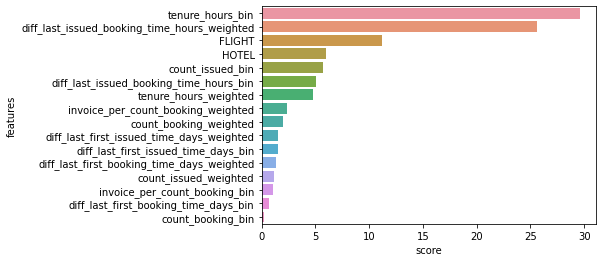

In [64]:
#calculate and calculate features importances
fp = pd.DataFrame(catbo.feature_importances_,Xtrain.columns).reset_index().rename(columns={'index':'features',0:'score'}).sort_values('score',ascending=False)
sns.barplot(fp['score'],fp['features'])

In [65]:
fp

,features,score
10,tenure_hours_bin,29.645902
7,diff_last_issued_booking_time_hours_weighted,25.626143
15,FLIGHT,11.216788
14,HOTEL,5.975551
0,count_issued_bin,5.706004
6,diff_last_issued_booking_time_hours_bin,5.045629
11,tenure_hours_weighted,4.806025
3,invoice_per_count_booking_weighted,2.335927
5,count_booking_weighted,1.983583
9,diff_last_first_issued_time_days_weighted,1.547778


Interpretasi : plot distribution for selected cut off from predict_proba while ks plot is measureming the level of discrimination of the model by comparing cumulative distributions good and bad.
The ks score above 20% means the model is feasible


None

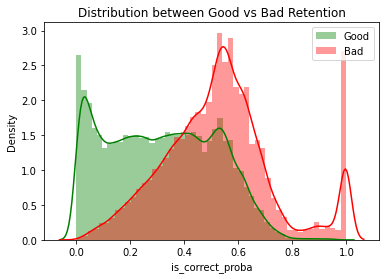

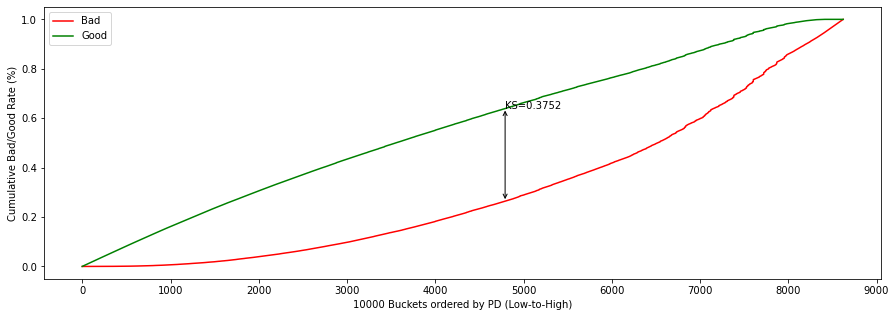

In [67]:
# build function to show KS and distribution bwetween good vs bad
def plot_auc(ax, y_train=[], y_train_pred=[], y_test=[], y_test_pred=[]):
    
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        fpr_train, tpr_train, _ = roc_curve(y_train,y_train_pred)
        roc_auc_train = metrics.auc(fpr_train, tpr_train)
        ax.plot(fpr_train, tpr_train)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):
        fpr_test, tpr_test, _ = roc_curve(y_test,y_test_pred)
        roc_auc_test = metrics.auc(fpr_test, tpr_test)
        ax.plot(fpr_test, tpr_test)        
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curve')
    train_text = None
    test_text = None
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        train_text = 'TRAIN auc = {:.2f}'.format(roc_auc_train)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):
        test_text = 'TEST  auc = {:.2f}'.format(roc_auc_test)
    leg = []
    if ((len(y_train)>0)&(len(y_train_pred)>0)):
        leg.append(train_text)
    if ((len(y_test)>0)&(len(y_test_pred)>0)):
        leg.append(test_text)
    ax.legend(leg)    
def plot_distr(data, train_or_test, label_actual='actual', label_proba='proba', n_sample=None):
    N = data.shape[0]
    listidx = data.index.values.tolist()
    disp = data.loc[listidx,:]
    disp = disp.rename({'pred':'ProbDefault'},axis=1)
    ax = sns.distplot(a=disp.loc[disp[label_actual]==0,label_proba], hist=True, color = 'Green', label='Good')
    ax = sns.distplot(a=disp.loc[disp[label_actual]==1,label_proba], hist=True, color = 'Red', label='Bad')
    ax.legend()
    ax = plt.title("Distribution between Good vs Bad Retention")
def plot_ks(y_pred, y_true, N=10, bins=[], isplot=True):
    result = pd.DataFrame({
        "predicted":y_pred,
        "bad":y_true.astype(int),
        "good":np.abs(1-y_true).astype(int)
    })
    result = result.sort_values(by='predicted', ascending=False)
    if len(bins)>1:
        result['bucket'] = pd.cut(y_pred, bins=bins)
    else:
        result['bucket'] = pd.qcut(result.predicted, q=N, labels=False, duplicates='drop')
        result['bucket'] = result['bucket'] + 1    
    grouped = result.groupby('bucket',as_index=False)
    agg = pd.DataFrame({
        "min_scr":grouped.min().predicted, 
        "max_scr":grouped.max().predicted,
        "tot_bad": grouped.sum().bad,
        "tot_good":grouped.count().good - grouped.sum().bad,
        "total":grouped.count().bad
    })
    agg = agg[['min_scr']+[x for x in agg.columns.values if x!='min_scr']]
    agg['pct_bad'] = (agg.tot_bad / result.bad.sum())#.apply('{0:.2%}'.format)
    agg['pct_good'] = (agg.tot_good / result.good.sum())#.apply('{0:.2%}'.format)
    agg['odds'] = (agg.tot_good / agg.tot_bad).apply('{0:.2f}'.format)
    agg['cum_bad'] = agg.pct_bad.cumsum()
    agg['cum_good'] = agg.pct_good.cumsum()
    agg['ks'] = np.abs(np.round(agg.cum_bad - agg.cum_good, 4))
    agg['max_ks'] = agg.ks.apply(lambda x: '<----' if x == agg.ks.max() else '')    
    if isplot:
        fig,ax = plt.subplots(1,1)
        fig.set_size_inches(15,5)
        ax.plot(agg.index.values, agg.cum_bad, color='red', label='Bad')
        ax.plot(agg.index.values, agg.cum_good, color='green', label='Good')
        plt.xticks(np.arange(0, N, N/10))
        _ = ax.set_xlabel('{} Buckets ordered by PD (Low-to-High)'.format(N))
        _ = ax.set_ylabel('Cumulative Bad/Good Rate (%)'.format(N))
        ax.legend()
        ks_max_idx = agg.ks.argmax()
        ks_max_good = agg.cum_good[ks_max_idx]
        ks_max_bad = agg.cum_bad[ks_max_idx]
        plt.annotate(s=''.format(agg.ks.max()), xy=(ks_max_idx,ks_max_good), xytext=(ks_max_idx,ks_max_bad), arrowprops=dict(arrowstyle='<->'))
        plt.text(ks_max_idx, ks_max_good, "KS={}".format(agg.ks.max()))   
    return agg
#plot distribution between good(non-default) vs bad (default) and plot KS.
print("""Interpretasi : plot distribution for selected cut off from predict_proba while ks plot is measureming the level of discrimination of the model by comparing cumulative distributions good and bad.
The ks score above 20% means the model is feasible""")
import seaborn as sns 
result_mod_correct = Xtrain.copy()
result_mod_correct['is_correct_proba'] = catbo.predict_proba(Xtrain)[:,1]
result_mod_correct['is_correct_actual'] = ytrain
data = result_mod_correct.copy()
display(plot_distr(data, train_or_test='All Population', label_actual='is_correct_actual', label_proba='is_correct_proba'))
display(result_ks = plot_ks(data.is_correct_proba, data.is_correct_actual, N=10000)) 

In [77]:
dftrain['prob_default'] = catbo.predict_proba(Xtrain)[:,1]
dftest['prob_default'] = catbo.predict_proba(Xtest)[:,1]
dfpop = pd.concat([dftrain,dftest],axis=0)
############## simple methodology to create scores into segment ##############
#1) apply the model on the testing. The testing with the result are provided in the following dataframe.
test = dftest[['primary_sales_product_type','prob_default']]
#2) divide the scoring data into 10 deciles based on the high to low score proabability
test['Decile'] = pd.qcut(test['prob_default'], 10, labels=False)
test = test[['Decile','prob_default']]
test = test.groupby('Decile').aggregate(['count','mean'])
test.columns = ['_'.join(col) for col in test.columns.values]
#3) classify high, medium, and low prospensity customers based on the decile grouping and average likelihood score
#   for each decile
test = test.rename(columns={'prob_default_count':'number of customers','prob_default_mean':'average likelihood score'}).reset_index()
test['segment'] = np.where(test['average likelihood score']<=0.061285,'low',
                           np.where(test['average likelihood score']>0.189113,'high','medium'))
test

,Decile,number of customers,average likelihood score,segment
0,0,4121,0.036401,low
1,1,4120,0.130000,medium
2,2,4120,0.223647,high
3,3,4120,0.305366,high
4,4,4120,0.375613,high
5,5,4120,0.439697,high
6,6,4126,0.502083,high
7,7,4116,0.552387,high
8,8,4118,0.612939,high
9,9,4121,0.791789,high


In [78]:
############## function to build risk and default rates by others features##############
def get_risk_rank_table(y_pred, y_true, N=10, bins=[], outstanding_amount=[]):

    os_amt = np.zeros(len(y_pred)) if len(outstanding_amount)==0 else np.double(outstanding_amount)
    result = pd.DataFrame({
        "predicted":y_pred,
        "osamount":os_amt,
        "bad":y_true.astype(int),
        "good":np.abs(1-y_true).astype(int),
        "badamount":y_true.astype(int) * os_amt,
        "goodamount":np.abs(1-y_true).astype(int) * os_amt
    })
    result = result.sort_values(by='predicted', ascending=False)
    if len(bins)>1:
        result['bucket'] = pd.cut(result['predicted'], bins=bins)
    else:
      # result['bucket'] = pd.qcut(result.predicted, q=N, labels=np.arange(N)+1)
        result['bucket'] = pd.qcut(result.predicted, q=N, labels=False, duplicates='drop')
        result['bucket'] = result['bucket'] + 1

    grouped = result.groupby(['bucket'],as_index=False)    

    agg = pd.DataFrame({
    "Proba_MIN":grouped.min().predicted, 
    "Proba_MAX":grouped.max().predicted,
    "Total_Bad": grouped.sum().bad,
    "Total_Good":grouped.sum().good,
    "Total_Population":grouped.count().bad,
    "Total_Bad_Amount":grouped.sum().badamount,
    "Total_Good_Amount":grouped.sum().goodamount,
    "Total_Population_Amount":grouped.sum().osamount,
    })

    # agg = agg.sort_index(by='min_scr').reset_index(drop=True)
    agg = agg[['Proba_MIN']+[x for x in agg.columns.values if x!='Proba_MIN']]

    agg['Rate_Bad'] = (agg.Total_Bad / agg.Total_Population)
    agg['Rate_Good'] = (agg.Total_Good / agg.Total_Population)

    agg['Cum_Rate_Bad'] = agg.Total_Bad.cumsum() / agg.Total_Population.cumsum()
    agg['Cum_Rate_Good'] = agg.Total_Good.cumsum() / agg.Total_Population.cumsum()
    agg['Cum_Rate_Appr_Rate'] = (agg.Total_Population.cumsum() / agg.Total_Population.sum())
    
    agg['Rate_Bad_Amount'] = (agg.Total_Bad_Amount / agg.Total_Population_Amount)
    agg['Rate_Good_Amount'] = (agg.Total_Good_Amount / agg.Total_Population_Amount)

    agg['Cum_Rate_Bad_Amount'] = agg.Total_Bad_Amount.cumsum() / agg.Total_Population_Amount.cumsum()
    agg['Cum_Rate_Good_Amount'] = agg.Total_Good_Amount.cumsum() / agg.Total_Population_Amount.cumsum()
    agg['Cum_Rate_Appr_Rate_Amount'] = (agg.Total_Population_Amount.cumsum() / agg.Total_Population_Amount.sum())
    
    if len(outstanding_amount)>0:
        agg = agg.loc[:,[
            'Proba_MIN','Proba_MAX',
            'Total_Population','Total_Bad',
            'Cum_Rate_Appr_Rate','Rate_Bad','Cum_Rate_Bad',
            'Total_Population_Amount','Total_Bad_Amount',
            'Cum_Rate_Appr_Rate_Amount','Rate_Bad_Amount','Cum_Rate_Bad_Amount'
        ]]
        agg = agg.rename({
            'Total_Population':'NoA_Population_Total',
            'Total_Bad':'NoA_Bad_Total',
            'Cum_Rate_Appr_Rate':'NoA_Approval_Rate',
            'Rate_Bad':'NoA_Bad_Rate',
            'Cum_Rate_Bad':'NoA_Bad_Rate_Cumulative',
            'Total_Population_Amount':'Amt_Population_Total',
            'Total_Bad_Amount':'Amt_Bad_Total',
            'Cum_Rate_Appr_Rate_Amount':'Amt_Approval_Rate',
            'Rate_Bad_Amount':'Amt_Bad_Rate',
            'Cum_Rate_Bad_Amount':'Amt_Bad_Rate_Cumulative'
        },axis=1)
    else:
        agg = agg.loc[:,[
            'Proba_MIN','Proba_MAX',
            'Total_Population','Total_Bad',
            'Cum_Rate_Appr_Rate','Rate_Bad','Cum_Rate_Bad',
        ]]
        agg = agg.rename({
            'Total_Population':'NoA_Population_Total',
            'Total_Bad':'NoA_Bad_Total',
            'Cum_Rate_Appr_Rate':'NoA_Approval_Rate',
            'Rate_Bad':'NoA_Bad_Rate',
            'Cum_Rate_Bad':'NoA_Bad_Rate_Cumulative'
        },axis=1)
    
    return agg

In [87]:
tbl_early_warning_risk = get_risk_rank_table(dfpop['prob_default'], dfpop.is_churn, N=10, 
                                             outstanding_amount=dfpop.invoice_per_count_issued_bin)
# add columns grade
tbl_early_warning_risk['Grade'] = pd.Series(['A1', 'A2','A3', 'A4', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3'])
tbl_early_warning_risk

,Proba_MIN,Proba_MAX,NoA_Population_Total,NoA_Bad_Total,NoA_Approval_Rate,NoA_Bad_Rate,NoA_Bad_Rate_Cumulative,Amt_Population_Total,Amt_Bad_Total,Amt_Approval_Rate,Amt_Bad_Rate,Amt_Bad_Rate_Cumulative,Grade
0,0.000339,0.077514,20601,545,0.100001,0.026455,0.026455,59306.0,1680.0,0.040068,0.028328,0.028328,A1
1,0.077519,0.179771,20601,2717,0.200003,0.131887,0.079171,87548.0,11130.0,0.099217,0.127130,0.087229,A2
2,0.179772,0.265920,20601,4749,0.300004,0.230523,0.129622,117045.0,27259.0,0.178295,0.232893,0.151835,A3
3,0.265922,0.343132,20602,6608,0.400011,0.320746,0.177404,141976.0,45502.0,0.274217,0.320491,0.210831,A4
4,0.343138,0.410841,20599,7895,0.500002,0.383271,0.218574,153378.0,58984.0,0.377842,0.384566,0.258479,B1
5,0.410843,0.472751,20612,9048,0.600057,0.438968,0.255323,163579.0,72351.0,0.488359,0.442300,0.300078,B2
6,0.472755,0.529566,20589,10274,0.700000,0.499004,0.290115,176830.0,89023.0,0.607829,0.503438,0.340049,B3
7,0.529567,0.577219,20696,11394,0.800463,0.550541,0.322800,195888.0,108132.0,0.740175,0.552009,0.377948,C1
8,0.577221,0.648273,20505,12414,0.899999,0.605413,0.354055,203151.0,122967.0,0.877428,0.605299,0.413512,C2
9,0.648307,0.999283,20601,16159,1.000000,0.784379,0.397088,181422.0,141132.0,1.000000,0.777921,0.458178,C3


In [88]:
cols = list(tbl_early_warning_risk)
cols = [cols[-1]] + cols[:-1]
tbl_early_warning_risk = tbl_early_warning_risk[cols]
tbl_early_warning_risk

,Grade,Proba_MIN,Proba_MAX,NoA_Population_Total,NoA_Bad_Total,NoA_Approval_Rate,NoA_Bad_Rate,NoA_Bad_Rate_Cumulative,Amt_Population_Total,Amt_Bad_Total,Amt_Approval_Rate,Amt_Bad_Rate,Amt_Bad_Rate_Cumulative
0,A1,0.000339,0.077514,20601,545,0.100001,0.026455,0.026455,59306.0,1680.0,0.040068,0.028328,0.028328
1,A2,0.077519,0.179771,20601,2717,0.200003,0.131887,0.079171,87548.0,11130.0,0.099217,0.127130,0.087229
2,A3,0.179772,0.265920,20601,4749,0.300004,0.230523,0.129622,117045.0,27259.0,0.178295,0.232893,0.151835
3,A4,0.265922,0.343132,20602,6608,0.400011,0.320746,0.177404,141976.0,45502.0,0.274217,0.320491,0.210831
4,B1,0.343138,0.410841,20599,7895,0.500002,0.383271,0.218574,153378.0,58984.0,0.377842,0.384566,0.258479
5,B2,0.410843,0.472751,20612,9048,0.600057,0.438968,0.255323,163579.0,72351.0,0.488359,0.442300,0.300078
6,B3,0.472755,0.529566,20589,10274,0.700000,0.499004,0.290115,176830.0,89023.0,0.607829,0.503438,0.340049
7,C1,0.529567,0.577219,20696,11394,0.800463,0.550541,0.322800,195888.0,108132.0,0.740175,0.552009,0.377948
8,C2,0.577221,0.648273,20505,12414,0.899999,0.605413,0.354055,203151.0,122967.0,0.877428,0.605299,0.413512
9,C3,0.648307,0.999283,20601,16159,1.000000,0.784379,0.397088,181422.0,141132.0,1.000000,0.777921,0.458178


In [89]:
tbl_early_warning_risk.to_csv('enak_enak.csv')

# Finish